# Tuning

In [3]:
# === Modify model capacity ===
class DenoiseModel(nn.Module):
    def __init__(self, img_channels=3, time_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        self.conv1 = nn.Conv2d(img_channels, 128, 3, padding=1)
        self.conv2 = nn.Conv2d(128, 256, 3, padding=1)
        self.time_dense1 = nn.Linear(time_dim, 256)

        self.conv3 = nn.Conv2d(256, 128, 3, padding=1)
        self.time_dense2 = nn.Linear(time_dim, 128)
        self.conv4 = nn.Conv2d(128, img_channels, 3, padding=1)

    def forward(self, x, t):
        t_embed = self.time_mlp(t)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x) + self.time_dense1(t_embed)[:, :, None, None])
        x = F.relu(self.conv3(x) + self.time_dense2(t_embed)[:, :, None, None])
        return self.conv4(x)

# Re-initialize model & optimizer
model = DenoiseModel(img_channels=IMG_CHANNELS).to(DEVICE)
optimizer = Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# EMA wrapper
ema_model = DenoiseModel(img_channels=IMG_CHANNELS).to(DEVICE)
ema_model.load_state_dict(model.state_dict())

def update_ema(model, ema_model, decay=0.999):
    with torch.no_grad():
        for ema_param, param in zip(ema_model.parameters(), model.parameters()):
            ema_param.data.mul_(decay).add_(param.data, alpha=1 - decay)

# Training loop with EMA
for epoch in range(EPOCHS):
    model.train()
    pbar = tqdm(train_loader, desc=f"[Round 1] Epoch {epoch+1}")
    for x, _ in pbar:
        x = x.to(DEVICE)
        t = torch.randint(0, TIMESTEPS, (x.size(0),), device=DEVICE).long()
        noisy, noise = forward_diffusion_sample(x, t)
        pred_noise = model(noisy, t)
        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        update_ema(model, ema_model)

        pbar.set_postfix(loss=loss.item())

# Sample from EMA model
print("🌀 Sampling from EMA model...")
fake_images = sample_ddpm(ema_model, n=NUM_EVAL_IMAGES)

[Round 1] Epoch 10: 100%|███████████████████████████████████████████████| 125/125 [07:21<00:00,  3.53s/it, loss=0.0639]


🌀 Sampling from EMA model...


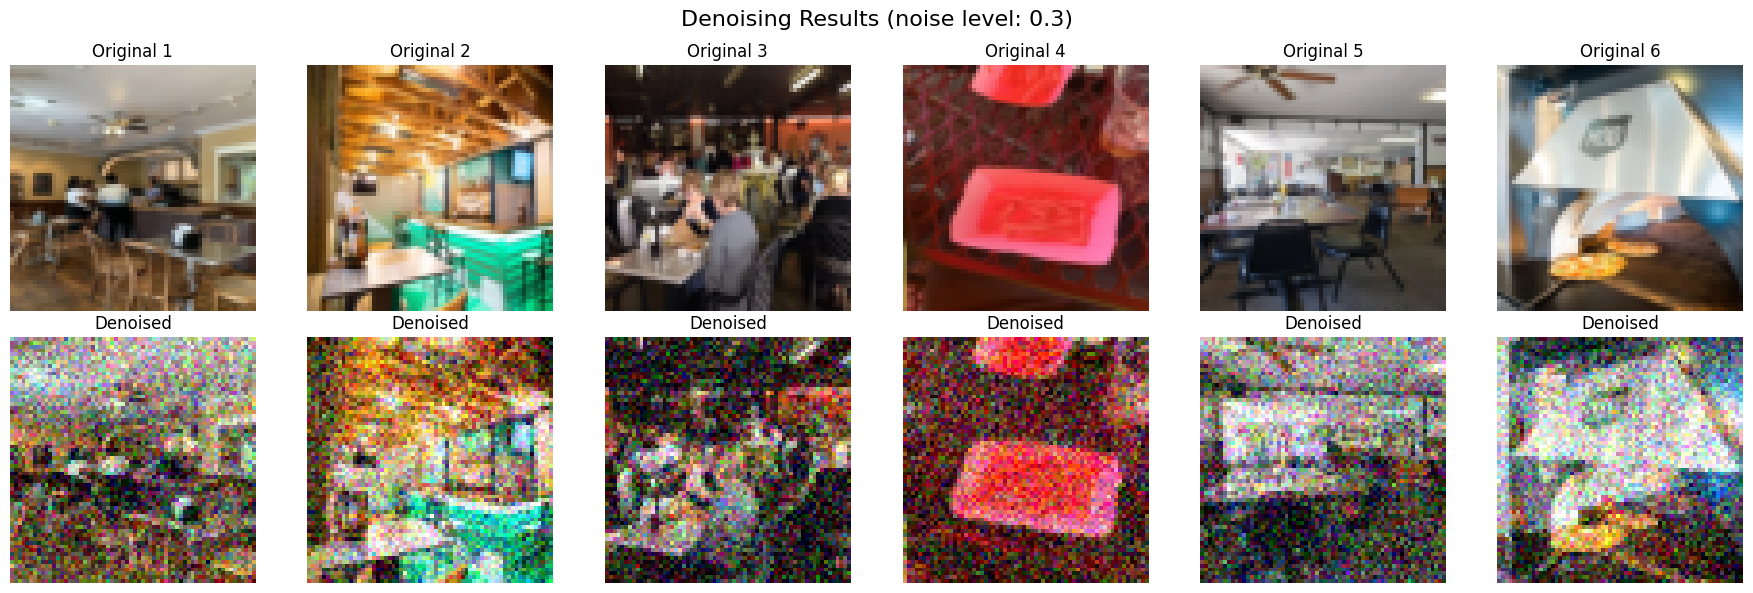

In [8]:
import warnings

def plot_original_denoised_noisy_grid(model, dataset, noise_level=0.3, count=6, save_path="corrected_denoising.png"):
    warnings.filterwarnings("ignore")  # Ignore all warnings here
    model.eval()

    # Create directory if needed
    dir_name = os.path.dirname(save_path)
    if dir_name != '':
        os.makedirs(dir_name, exist_ok=True)

    originals = torch.stack([dataset[i][0] for i in range(count)]).to(model.device)
    t = torch.full((count,), int(noise_level * model.timesteps), dtype=torch.long, device=model.device)
    noise = torch.randn_like(originals)
    noisy = model.q_sample(originals, t, noise)
    denoised = model.denoise(noisy, t)

    def denorm(x): return (x + 1) / 2.0
    originals = denorm(originals).cpu()
    denoised = denorm(denoised).cpu()

    fig, axes = plt.subplots(2, count, figsize=(count * 3, 6))
    for i in range(count):
        axes[0, i].imshow(np.transpose(originals[i].detach().cpu().numpy(), (1, 2, 0)))
        axes[0, i].set_title(f"Original {i+1}")
        axes[0, i].axis("off")

        axes[1, i].imshow(np.transpose(denoised[i].detach().cpu().numpy(), (1, 2, 0)))
        axes[1, i].set_title("Denoised")
        axes[1, i].axis("off")

    plt.suptitle(f"Denoising Results (noise level: {noise_level})", fontsize=16)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

    psnrs = []
    for i in range(count):
        mse = mean_squared_error(
            originals[i].detach().cpu().numpy().flatten(),
            denoised[i].detach().cpu().numpy().flatten()
        )
        psnr = -10 * np.log10(mse + 1e-10)
        psnrs.append(psnr)

    avg_psnr = np.mean(psnrs)
plot_original_denoised_noisy_grid(ddpm, test_dataset, noise_level=0.3, count=6)